In [ ]:
import pandas as pd
import numpy as np

FILE = "Supply chain logisitcs problem.xlsx"

sheets = pd.read_excel(FILE, sheet_name=None)

def clean_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return df

for k in sheets:
    sheets[k] = clean_cols(sheets[k])

In [ ]:
orders = sheets["OrderList"]
freight = sheets["FreightRates"]
wh_costs = sheets["WhCosts"]
wh_cap = sheets["WhCapacities"]
products = sheets["ProductsPerPlant"]
customers = sheets["VmiCustomers"]
plant_ports = sheets["PlantPorts"]

In [ ]:
for name, df in sheets.items():
    print("\n", name)
    print(df.isnull().sum())


 OrderList
order_id                0
order_date              0
origin_port             0
carrier                 0
tpt                     0
service_level           0
ship_ahead_day_count    0
ship_late_day_count     0
customer                0
product_id              0
plant_code              0
destination_port        0
unit_quantity           0
weight                  0
dtype: int64

 FreightRates
carrier         0
orig_port_cd    0
dest_port_cd    0
minm_wgh_qty    0
max_wgh_qty     0
svc_cd          0
minimum_cost    0
rate            0
mode_dsc        0
tpt_day_cnt     0
carrier_type    0
dtype: int64

 WhCosts
wh           0
cost_unit    0
dtype: int64

 WhCapacities
plant_id          0
daily_capacity    0
dtype: int64

 ProductsPerPlant
plant_code    0
product_id    0
dtype: int64

 VmiCustomers
plant_code    0
customers     0
dtype: int64

 PlantPorts
plant_code    0
port          0
dtype: int64


In [ ]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

In [ ]:
df = orders.merge(
    wh_costs,
    left_on="plant_code",
    right_on="wh",
    how="left"
)

In [ ]:
df = df.merge(
    wh_cap,
    left_on="plant_code",
    right_on="plant_id",
    how="left"
)

In [ ]:
df = df.merge(
    plant_ports,
    on="plant_code",
    how="left"
)

In [ ]:
df = df.merge(
    freight,
    left_on=[
        "carrier",
        "origin_port",
        "destination_port",
        "service_level"
    ],
    right_on=[
        "carrier",
        "orig_port_cd",
        "dest_port_cd",
        "svc_cd"
    ],
    how="left"
)

In [ ]:
df = df[
    (df["weight"] >= df["minm_wgh_qty"]) &
    (df["weight"] <= df["max_wgh_qty"])
]

In [ ]:
df["freight_cost"] = np.maximum(
    df["minimum_cost"],
    df["weight"] * df["rate"]
)

In [ ]:
df["delay_days"] = (
    df["ship_late_day_count"]
)

In [ ]:
df["is_delayed"] = (
    df["delay_days"] > 0
)

In [ ]:
df["shipped_early"] = (
    df["ship_ahead_day_count"] > 0
)

In [ ]:
df["transit_days"] = df["tpt_day_cnt"]

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [ ]:
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
print("Before:", len(df))

df = df.drop_duplicates()

print("After:", len(df))

Before: 15402
After: 15402


In [ ]:
df["delay_cost"] = (
    df["delay_days"] *
    df["cost_unit"] *
    df["unit_quantity"]
)

In [ ]:
total_orders = len(df)

delayed_orders = df["is_delayed"].sum()

delay_rate = (
    delayed_orders /
    total_orders
) * 100

avg_delay = df.loc[
    df["is_delayed"],
    "delay_days"
].mean()

total_delay_cost = df["delay_cost"].sum()

print("="*50)

print("Total Orders:", total_orders)

print("Delayed Orders:", delayed_orders)

print(f"Delay Rate: {delay_rate:.2f}%")

print(f"Average Delay: {avg_delay:.2f}")

print(f"Total Delay Cost: ${total_delay_cost:,.2f}")

Total Orders: 15402
Delayed Orders: 378
Delay Rate: 2.45%
Average Delay: 1.90
Total Delay Cost: $475,265.86


In [ ]:
df.to_csv(
    "supply_chain_cleaned.csv",
    index=False
)

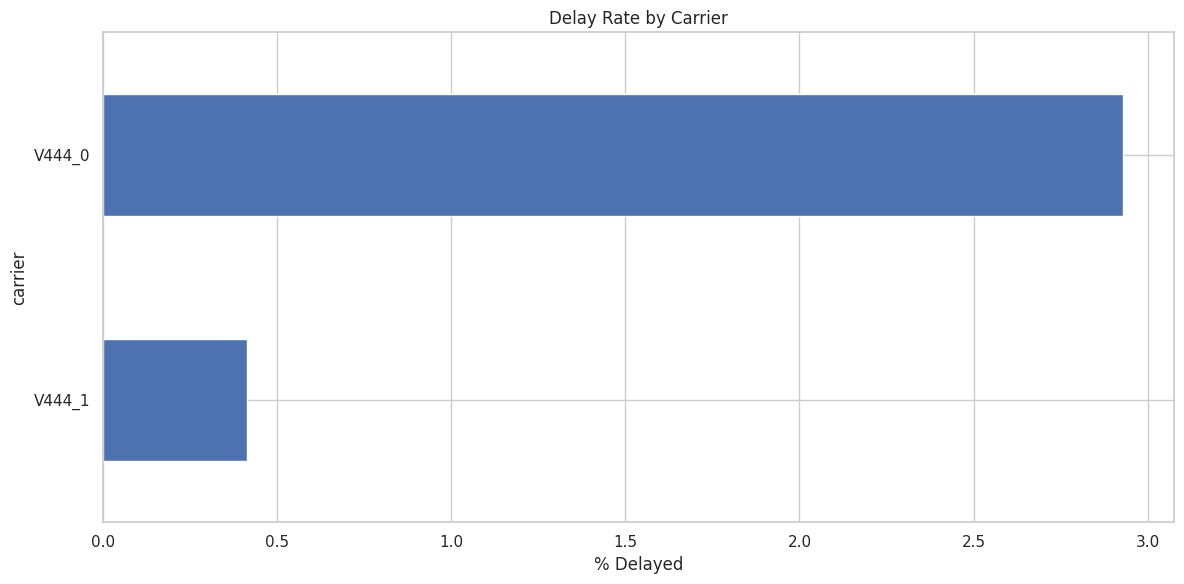

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

carrier_delay = (
    df.groupby("carrier")["is_delayed"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(12,6))

carrier_delay.plot(kind="barh")

plt.title("Delay Rate by Carrier")

plt.xlabel("% Delayed")

plt.tight_layout()

plt.savefig("chart_01_delay_by_carrier.png")
plt.show()

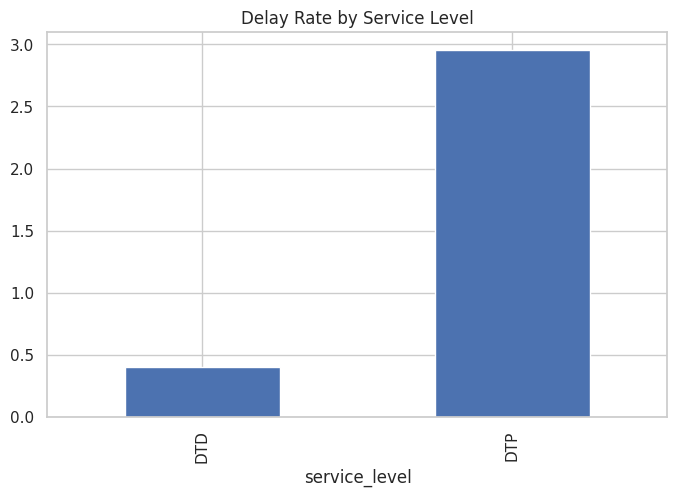

In [ ]:
service = (
    df.groupby("service_level")
    ["is_delayed"]
    .mean()
    .mul(100)
)

service.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Delay Rate by Service Level")

plt.savefig("chart_02_service_level.png")
plt.show()

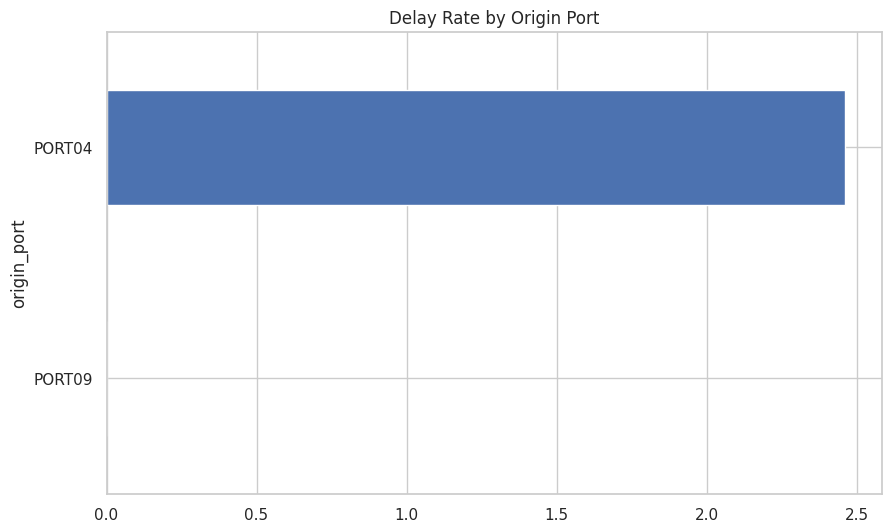

In [ ]:
origin = (
    df.groupby("origin_port")
    ["is_delayed"]
    .mean()
    .mul(100)
    .sort_values()
)

origin.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Delay Rate by Origin Port")

plt.savefig("chart_03_origin_port.png")
plt.show()

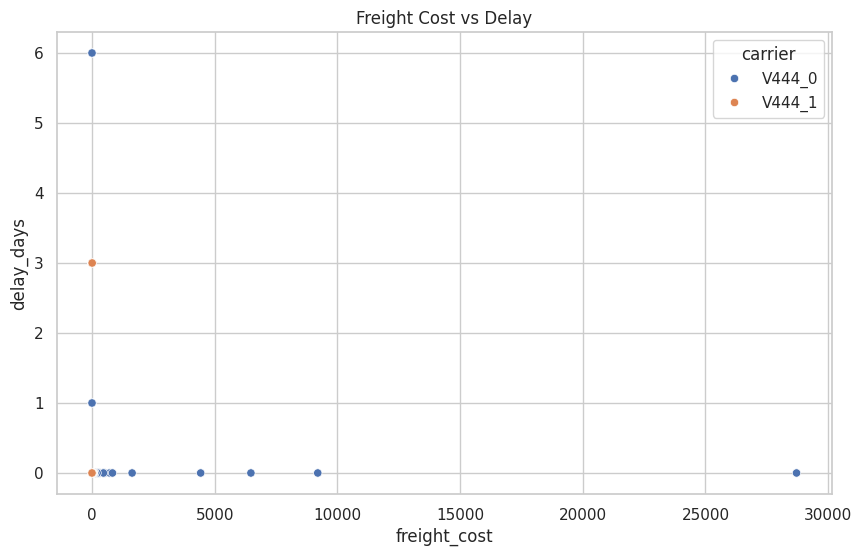

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="freight_cost",
    y="delay_days",
    hue="carrier"
)

plt.title("Freight Cost vs Delay")

plt.savefig("chart_04_cost_vs_delay.png")

plt.show()

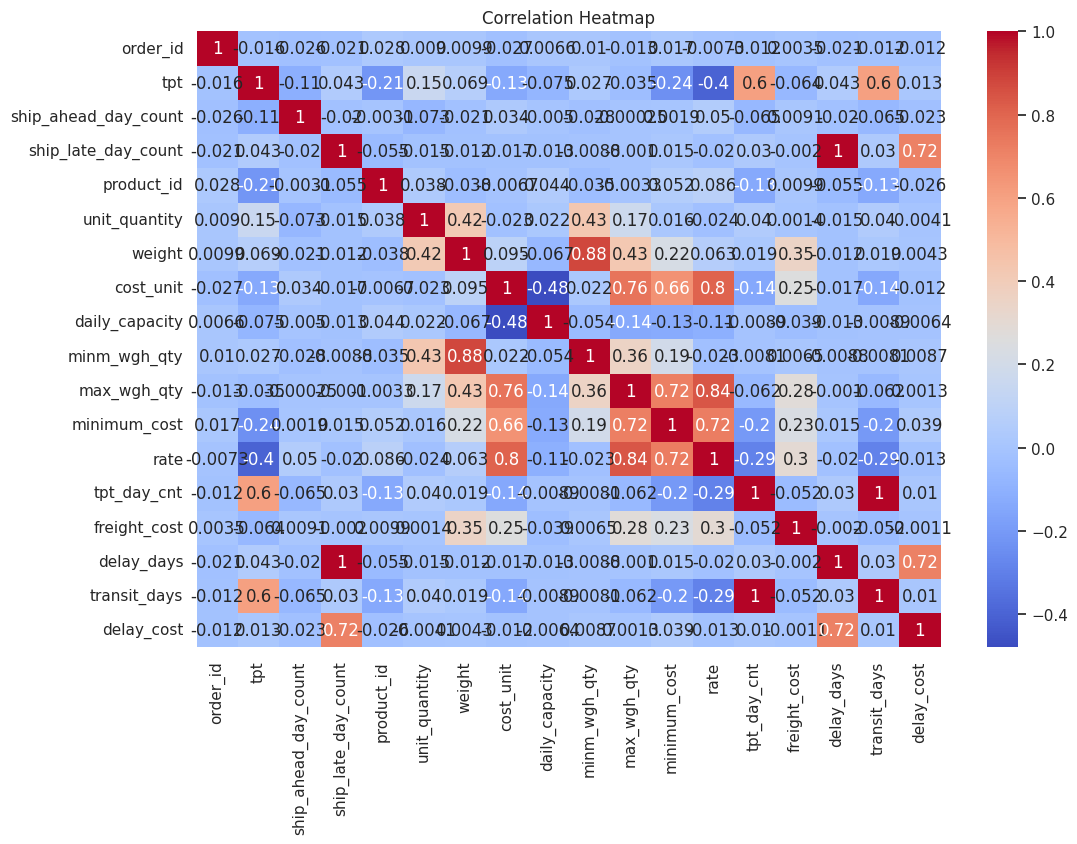

In [ ]:
plt.figure(figsize=(12,8))

corr = (
    df.select_dtypes(include=np.number)
    .corr()
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("chart_05_heatmap.png")

plt.show()